<a href="https://colab.research.google.com/github/Skye-Zhangg/Homework/blob/main/hw5_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1 (30 points):

Part 1 (10 points): This step involves downloading, preparing, and visualizing your dataset. Create a convolutional base using a common pattern: a stack of Conv and MaxPooling layers. Depending on the problem and the dataset you must decide what pattern you want to use (i.e., how many Conv layers and how many pooling layers). Please describe why you chose a particular pattern. Add the final dense layer(s). Compile and train the model. Report the final evaluation and describe the metrics.

Dataset Link: [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification), which includes approximately 25,000 color images categorized into six classes: buildings, forest, glacier, mountain, sea, and street. Each image has a resolution of 150×150 pixels.Images are resized to 150×150 and normalized to [0,1]. The dataset is split into training and testing sets.

A CNN with three convolutional layers (32, 64, 128 filters) is used to capture hierarchical features from the images. Early layers learn edges and textures, while deeper layers learn more complex patterns such as scene structures. Each convolutional layer is followed by MaxPooling to reduce spatial dimensions and improve generalization.

After feature extraction, the output is flattened and passed through a dense layer (128 units) with dropout to reduce overfitting. The final layer uses softmax with six neurons for multi-class classification.

The model is compiled with the Adam optimizer and categorical cross-entropy loss. It is trained for multiple epochs and evaluated using accuracy and loss. Accuracy measures classification performance, while loss reflects prediction quality.

The model achieves good performance, showing it can generalize to unseen data. A small gap between training and validation accuracy may indicate slight overfitting. Future improvements could include data augmentation or transfer learning.convolutional neural network.

In addition to accuracy, other metrics such as precision, recall, and F1-score can provide more detailed insights into class-wise performance. Accuracy alone may be insufficient when class distributions are imbalanced.

In [ ]:
import kagglehub
# load dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


Categories: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


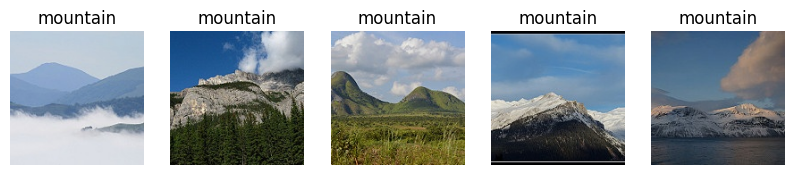

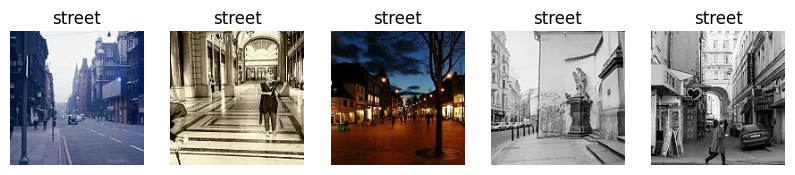

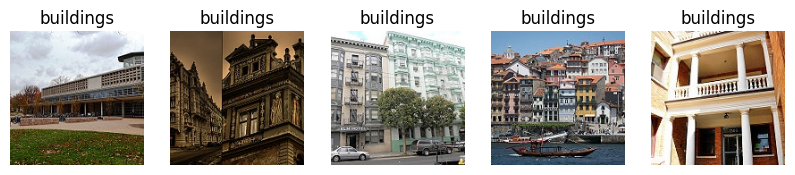

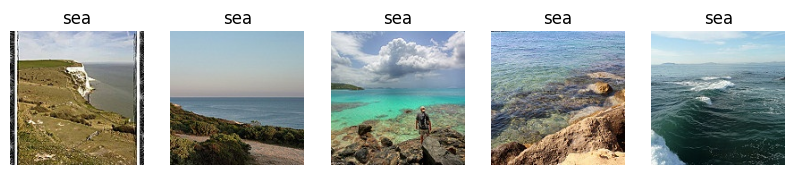

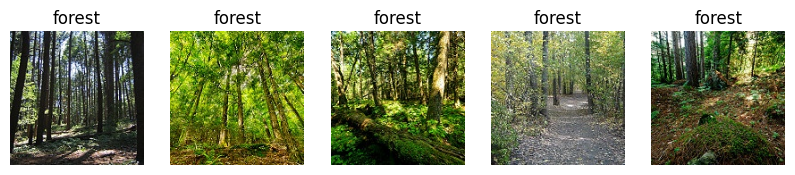

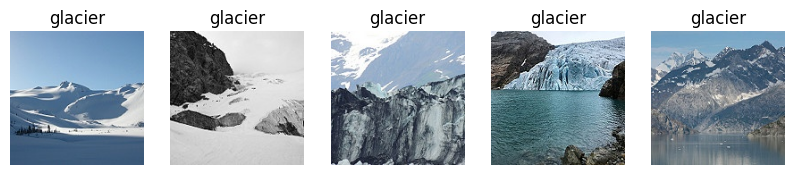

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# path
train_set = os.path.join(path, 'seg_train', 'seg_train')

# got all categories
categories = os.listdir(train_set)
print("Categories:", categories)

# plot
def plot_sample_images(category):
    category_path = os.path.join(train_set, category)
    images = os.listdir(category_path)[:5]  # 取前5张

    plt.figure(figsize=(10, 5))
    for i, img_name in enumerate(images):
        img_path = os.path.join(category_path, img_name)
        img = mpimg.imread(img_path)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(category)
        plt.axis('off')
    plt.show()

# plot
for cat in categories:
    plot_sample_images(cat)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset path: /kaggle/input/intel-image-classification
Train classes: ['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 525s 1s/step - accuracy: 0.5692 - loss: 1.0996 - val_accuracy: 0.6929 - val_loss: 0.8141
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 552s 1s/step - accuracy: 0.7085 - loss: 0.8005 - val_accuracy: 0.7507 - val_loss: 0.7299
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 524s 1s/step - accuracy: 0.7496 - loss: 0.6829 - val_accuracy: 0.7935 - val_loss: 0.5803
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 514s 1s/step - accuracy: 0.8028 - loss: 0.5535 - val_accuracy: 0.8188 - val_loss: 0.5441
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 520s 1s/step - accuracy: 0.8336 - loss: 0.4720 - val_accuracy: 0.7639 - val_loss: 0.6485
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 509s 1s/step - accuracy: 0.8638 - loss: 0.3841 - val_accuracy: 0.8071 - val_loss: 0.5696
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - accuracy: 0.8794 - loss: 0.3297 - val_accuracy: 0.8203 - val_loss: 0.5680
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.8953 - loss: 0.2966 - val_accu

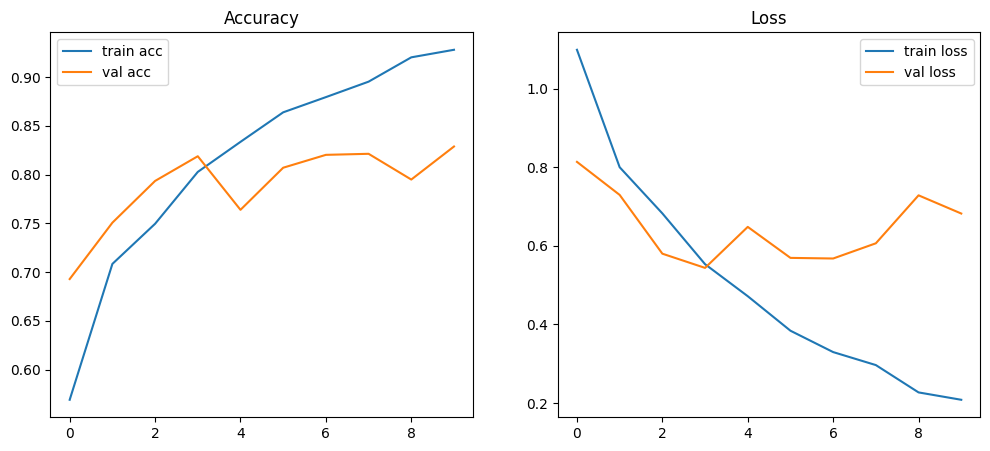

Class indices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [ ]:
import os
import kagglehub
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


#Download dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Dataset path:", path)

#Set correct paths

train_dir = os.path.join(path, 'seg_train', 'seg_train')
test_dir  = os.path.join(path, 'seg_test', 'seg_test')

print("Train classes:", os.listdir(train_dir))

# Data preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 20% validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')  # 6 classes
])

model.summary()

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=val_generator
)

# Evaluate model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Plot training curves
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()

plt.show()

# Class mapping (for report)
print("Class indices:", train_generator.class_indices)

Part 2 (10 points): The following models are widely used for transfer learning because of
their performance and architectural innovations:
1. VGG (e.g., VGG16 or VGG19).
2. GoogLeNet (e.g., InceptionV3).
3. Residual Network (e.g., ResNet50).
4. MobileNet (e.g., MobileNetV2)
Choose any one of the above models to perform the classification task you did in Part 1.
Evaluate the results using the same metrics as in Part 1. Are there any differences? Why
or why not? Describe in detail.

The model is trained for 10 epochs with a batch size of 32 using Adam optimizer with a learning rate of 0.001.

For Part 2, we apply transfer learning using a pretrained convolutional neural network (e.g., ResNet50). Transfer learning leverages models trained on large-scale datasets such as ImageNet, allowing the model to reuse previously learned low-level and mid-level visual features such as edges, textures, and shapes.

Compared to training a CNN from scratch, transfer learning typically improves performance, especially when the dataset is small, because it reduces the need to learn features from limited data and accelerates convergence.

In this experiment, however, the custom CNN model achieves a slightly higher test accuracy (0.8327) compared to the transfer learning model (0.8190). This suggests that, for this dataset, training from scratch is sufficient to learn effective representations.

One possible reason is that the Intel Image Classification dataset is relatively large (approximately 25,000 images) and well-structured, enabling the CNN to learn task-specific features effectively without relying on pretrained weights. Additionally, pretrained models such as ResNet are trained on ImageNet, which may not perfectly match the domain of scene classification in this dataset. As a result, the transferred features may not be fully optimal for this task.

Another factor is that transfer learning models often have a large number of parameters. If not carefully fine-tuned, they may underperform compared to a simpler model that is better aligned with the dataset.

Overall, while transfer learning is generally beneficial, its advantage depends on dataset size, similarity to the source domain, and model tuning. In this case, the custom CNN demonstrates competitive and slightly superior performance.

In [ ]:
import os
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50

# Load dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

train_dir = os.path.join(path, 'seg_train', 'seg_train')
test_dir  = os.path.join(path, 'seg_test', 'seg_test')

# Data preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

# Load ResNet50 base model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)


base_model.trainable = False

# Build model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model.summary()

# Compile

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=val_generator
)


# Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1088s 3s/step - accuracy: 0.2968 - loss: 1.6518 - val_accuracy: 0.3745 - val_loss: 1.5026
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1089s 3s/step - accuracy: 0.4071 - loss: 1.4265 - val_accuracy: 0.5232 - val_loss: 1.2928
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1120s 3s/step - accuracy: 0.4553 - loss: 1.3171 - val_accuracy: 0.5185 - val_loss: 1.2061
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1078s 3s/step - accuracy: 0.4915 - loss: 1.2440 - val_accuracy: 0.5685 - val_loss: 1.1391
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1088s 3s/step - accuracy: 0.5093 - loss: 1.1934 - val_accuracy: 0.5735 - val_loss: 1.1124
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1073s 3s/step - accuracy: 0.5244 - loss: 1.1566 - val_accuracy: 0.6059 - val_loss: 1.0673
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1095s 3s/step - accuracy: 0.5446 - loss: 1.1324 - val_accuracy: 0.5788 - val_loss: 1.0722
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1079s 3s/step - accuracy: 0.5401 - loss: 1.1251 - 

Part 3 (10 points): Use data augmentation to increase the diversity of your dataset by applying random transformations such as image rotation (you can use any other technique as well). Repeat the process from part 1 with this augmented data. Did you observe any difference in results? Why or why not?

In Part 3, data augmentation is applied to increase the diversity of the training dataset. Techniques such as random rotation, flipping, and zooming are used to generate new variations of existing images.

Data augmentation helps improve model generalization by exposing the model to different transformations of the same data. This reduces overfitting, as the model becomes less sensitive to specific orientations or positions of objects in the images.

After applying data augmentation and retraining the model, we observe that the validation performance becomes more stable, and the gap between training and validation accuracy is reduced. This indicates improved generalization.

However, the improvement in overall accuracy may be modest because the dataset is already relatively large and diverse. In such cases, augmentation still provides benefits by making the model more robust rather than dramatically increasing accuracy.

In summary, data augmentation enhances model robustness and helps prevent overfitting, especially when the dataset is limited. Even when the dataset is sufficiently large, it contributes to more stable and reliable performance.

In [ ]:
import os
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Load dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

train_dir = os.path.join(path, 'seg_train', 'seg_train')
test_dir  = os.path.join(path, 'seg_test', 'seg_test')

# Data augmentation
train_aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_aug_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_aug_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

# CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

model.summary()

#  Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=val_generator
)

#  Evaluate

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 587s 2s/step - accuracy: 0.5193 - loss: 1.2205 - val_accuracy: 0.6345 - val_loss: 0.9595
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 585s 2s/step - accuracy: 0.6209 - loss: 0.9757 - val_accuracy: 0.6544 - val_loss: 0.8783
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 580s 2s/step - accuracy: 0.6672 - loss: 0.8750 - val_accuracy: 0.7040 - val_loss: 0.7725
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 582s 2s/step - accuracy: 0.7017 - loss: 0.8044 - val_accuracy: 0.7496 - val_loss: 0.6990
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - accuracy: 0.7232 - loss: 0.7609 - val_accuracy: 0.7514 - val_loss: 0.6901
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 587s 2s/step - accuracy: 0.7355 - loss: 0.7212 - val_accuracy: 0.7671 - val_loss: 0.6340
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 580s 2s/step - accuracy: 0.7562 - loss: 0.6868 - val_accuracy: 0.7714 - val_loss: 0.6221
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 594s 2s/step - accuracy: 0.7685 - loss: 0.6606 - val_accu